In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks")

In [112]:
raw_data_folder = '../data/raw'
processed_data_folder = '../data/processed'
# filename = "deb_reach_birth_noise_1p000_kapnoise_20p0_seed_42.csv"
# filename = "sample4D_lhs_N_200000_g_1em3_1e2_k_m4_1_f_0p1_1_ddec_1.csv"
filename = "sample4D_lhs_N_200000_g_1em3_1e2_k_m4_1_f_0p1_1_ddec_1_getlb2.csv"

df = pd.read_csv(f'../data/raw/{filename}', index_col=0)
col_types = {
    'params': df.columns[0:4].tolist(),
    'simul': df.columns[4:9].tolist(),
    'log': df.columns[9:].tolist()
}
print(col_types)




{'params': ['g', 'k', 'v_Hb', 'f'], 'simul': ['lb', 'tb', 'lb<f', 'k*vHb<c', 'reached_birth'], 'log': ['success', 'execution_time', 'error_type', 'error_message']}


In [113]:
df = df[df['execution_time'] > 0].copy()
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=col_types['params'])

df['success'] = df['success'].astype(bool)
df['reached_birth'] = df['reached_birth'].astype(bool)
df['lb<f'] = df['lb<f'].astype(bool)
df['k*vHb<c'] = df['k*vHb<c'].astype(bool)

df

,g,k,v_Hb,f,lb,tb,lb<f,k*vHb<c,reached_birth,success,execution_time,error_type,error_message
Row,,,,,,,,,,,,,
1,0.029917,0.460685,0.098951,0.834764,0.364070,40.323831,True,True,True,True,0.202437,none,NaN
2,0.031694,0.214933,0.078002,0.537721,0.277036,29.603417,True,True,True,True,0.203712,none,NaN
3,0.005513,0.001178,24.571455,0.876544,NaN,NaN,False,False,False,False,0.963328,none,NaN
4,0.050763,3.752228,0.012638,0.516606,0.358221,25.046061,True,True,True,True,0.198441,none,NaN
5,1.044990,6.191878,0.000212,0.238960,0.071471,0.307795,True,False,False,True,0.189789,none,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199987,0.002099,0.000335,0.004763,0.242510,0.057945,87.173909,True,True,True,True,0.102550,none,NaN
199988,0.599086,0.000433,206.329166,0.480281,NaN,NaN,False,False,False,False,0.102777,none,NaN
199990,0.002987,0.016311,168.967537,0.819807,NaN,NaN,False,False,False,False,0.099099,none,NaN


In [114]:
df['error_type'].value_counts()

error_type
none                  199383
time_limit_reached       606
Name: count, dtype: int64

In [115]:
df['success'].mean()


np.float64(0.6703468690777993)

In [116]:
df['reached_birth'].mean()

np.float64(0.4227432508787983)

In [117]:
df.groupby(['success', 'reached_birth']).size()/ len(df)

success  reached_birth
False    False            0.329653
True     False            0.247604
         True             0.422743
dtype: float64

In [118]:
248 / (248+423)

0.36959761549925485

In [119]:
# Filter out rows with infinite values
df = df[df['execution_time'] > 0].copy()
# Filter out too small values for k*vHb
#df = df[df['k'] * df['v_Hb'] > 1e-16].copy()
df

,g,k,v_Hb,f,lb,tb,lb<f,k*vHb<c,reached_birth,success,execution_time,error_type,error_message
Row,,,,,,,,,,,,,
1,0.029917,0.460685,0.098951,0.834764,0.364070,40.323831,True,True,True,True,0.202437,none,NaN
2,0.031694,0.214933,0.078002,0.537721,0.277036,29.603417,True,True,True,True,0.203712,none,NaN
3,0.005513,0.001178,24.571455,0.876544,NaN,NaN,False,False,False,False,0.963328,none,NaN
4,0.050763,3.752228,0.012638,0.516606,0.358221,25.046061,True,True,True,True,0.198441,none,NaN
5,1.044990,6.191878,0.000212,0.238960,0.071471,0.307795,True,False,False,True,0.189789,none,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199987,0.002099,0.000335,0.004763,0.242510,0.057945,87.173909,True,True,True,True,0.102550,none,NaN
199988,0.599086,0.000433,206.329166,0.480281,NaN,NaN,False,False,False,False,0.102777,none,NaN
199990,0.002987,0.016311,168.967537,0.819807,NaN,NaN,False,False,False,False,0.099099,none,NaN


In [120]:
df[col_types['params']].describe()

,g,k,v_Hb,f
count,199989.000000,199989.000000,1.999890e+05,199989.000000
mean,8.685782,0.868606,1.928144e+02,0.550000
std,18.942806,1.894376,1.599443e+03,0.259808
min,0.001000,0.000100,1.499035e-07,0.100001
25%,0.017784,0.001778,3.312734e-02,0.324999
50%,0.316255,0.031624,3.431635e-01,0.549999
75%,5.623831,0.562355,5.387517e+00,0.775001
max,99.998241,9.999598,8.447736e+04,0.999996


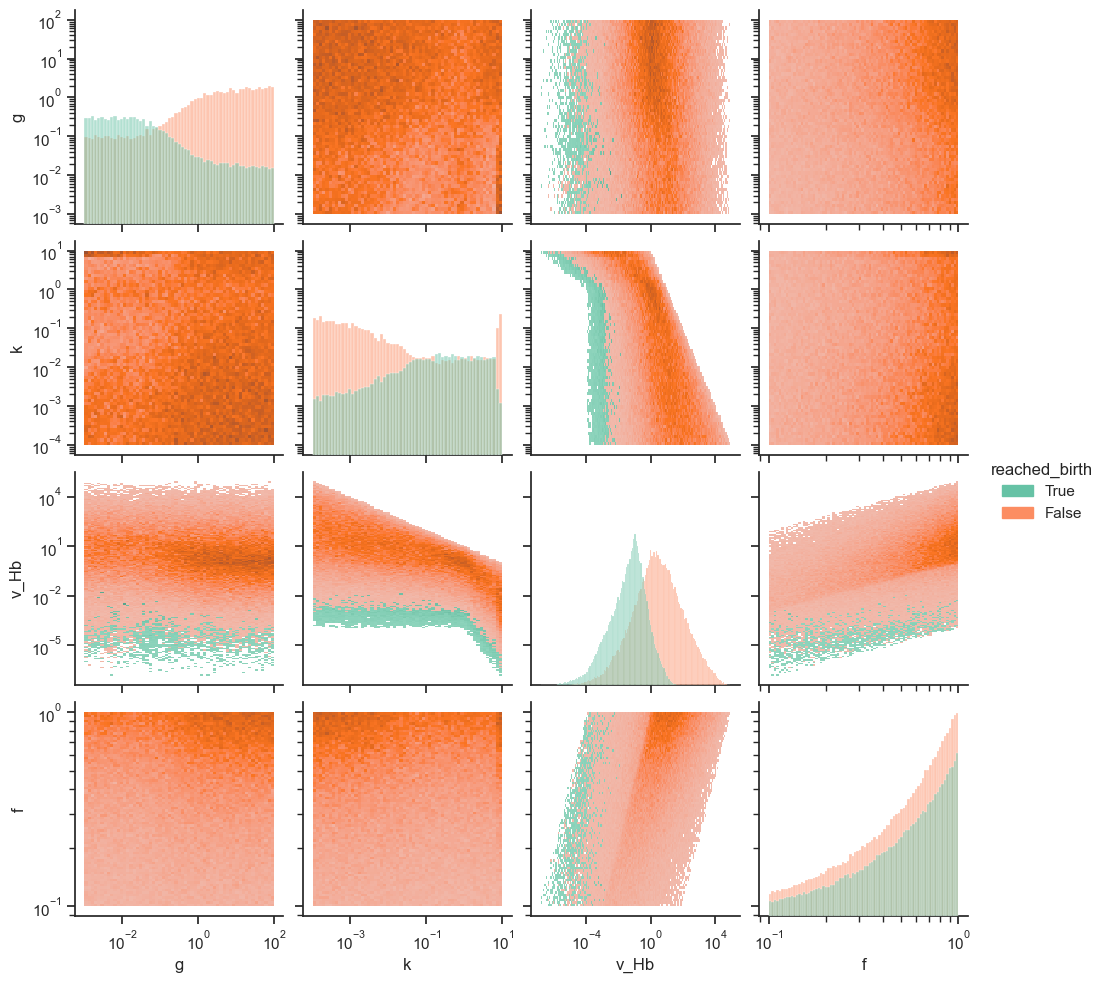

In [121]:
sns.pairplot(data=df, vars=col_types['params'],
             hue="reached_birth", palette="Set2", hue_order=[True, False],
             kind='hist', diag_kind="hist",
             plot_kws=dict(log_scale=True), diag_kws=dict(log_scale=True))


<Axes: xlabel='v_Hb', ylabel='Count'>

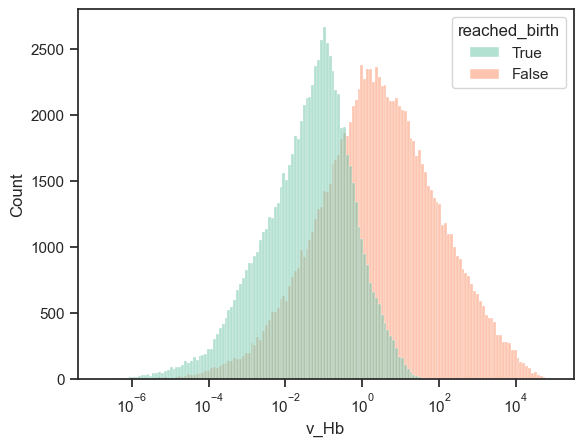

In [122]:
sns.histplot(data=df, x='v_Hb', hue='reached_birth', common_norm=False, log_scale=True,
             palette="Set2", hue_order=[True, False])

<Axes: xlabel='k', ylabel='Count'>

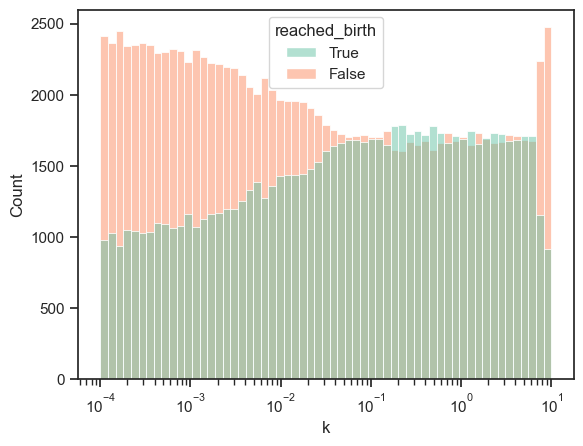

In [123]:
sns.histplot(data=df, x='k', hue='reached_birth', common_norm=False, log_scale=True,
             palette="Set2", hue_order=[True, False])


<Axes: xlabel='g', ylabel='Count'>

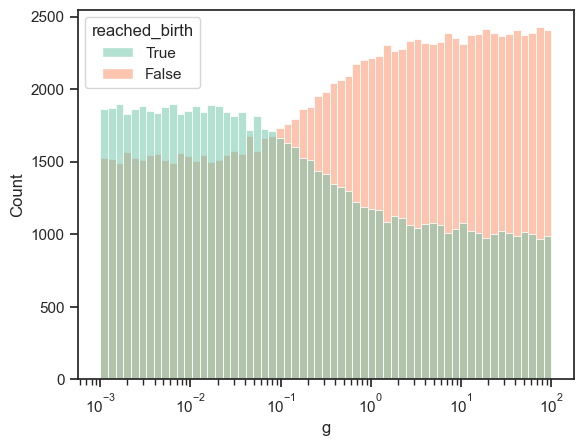

In [124]:
sns.histplot(data=df, x='g', hue='reached_birth', common_norm=False, log_scale=True,
             palette="Set2", hue_order=[True, False])

<Axes: xlabel='None', ylabel='Count'>

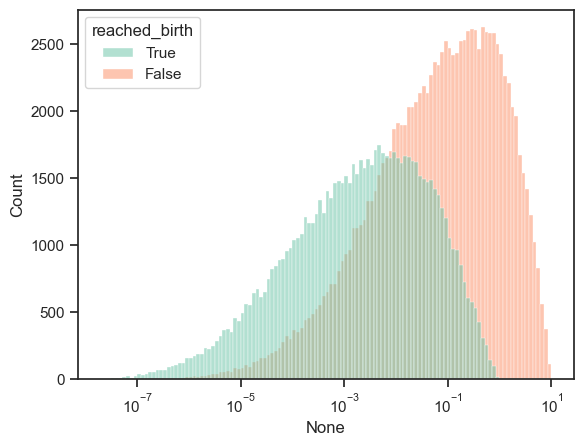

In [125]:
sns.histplot(x=df['k'] * df['v_Hb'], hue=df['reached_birth'], common_norm=False, log_scale=True,
             palette="Set2", hue_order=[True, False])


<Axes: xlabel='execution_time', ylabel='Count'>

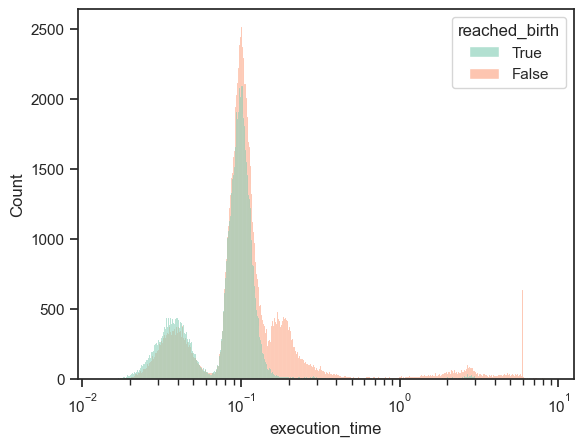

In [126]:
sns.histplot(data=df, x='execution_time', hue='reached_birth', common_norm=False, log_scale=True,
             palette="Set2", hue_order=[True, False])


In [127]:
df.groupby('success')['execution_time'].mean()

success
False    0.374173
True     0.114236
Name: execution_time, dtype: float64

In [128]:
0.273246 / 0.099804

2.7378261392328964

In [129]:
df['reached_birth'].mean()

np.float64(0.4227432508787983)

In [130]:
df[['lb<f', 'k*vHb<c']].value_counts()

lb<f   k*vHb<c
True   True       84544
False  False      78948
       True       27233
True   False       9264
Name: count, dtype: int64

In [131]:
df[['lb', 'tb']].isna().value_counts()

lb     tb   
False  False    134656
True   True      65321
False  True         12
Name: count, dtype: int64

## Split data and save

In [132]:
df.to_csv(f'{processed_data_folder}/deb_reach_birth.csv', index=False)
from sklearn.model_selection import train_test_split

train__frac = 0.8
test_frac = 0.1
val_frac = 0.1
# First split into train and temp (val + test)
train_df, temp_df = train_test_split(df, test_size=(1 - train__frac), random_state=42, stratify=df['reached_birth'])
# Then split temp into val and test
val_df, test_df = train_test_split(temp_df, test_size=(test_frac / (test_frac + val_frac)), random_state=42,
                                   stratify=temp_df['reached_birth'])
# Check sizes
print(f'Train size: {len(train_df)}, Val size: {len(val_df)}, Test size: {len(test_df)}')
# Save to csv
train_df.to_csv(f'{processed_data_folder}/train.csv', index=False)
val_df.to_csv(f'{processed_data_folder}/val.csv', index=False)
test_df.to_csv(f'{processed_data_folder}/test.csv', index=False)

Train size: 159991, Val size: 19999, Test size: 19999


In [136]:
test_df['execution_time'].describe()

count    19999.000000
mean         0.199756
std          0.608635
min          0.013211
25%          0.082274
50%          0.098427
75%          0.114838
max          7.959443
Name: execution_time, dtype: float64